In [2]:
from google.colab import drive
import sys

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Add your project root to Python's path
PROJECT_ROOT = '/content/drive/MyDrive/Vision/CNN'
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Import from your modular files
from config import NUM_CLASSES
from utils.dataloader import get_dataloaders 
from utils.engine import train_model                
from models.resnet import CustomResNet

# Initialize the data loaders
train_loader, val_loader, test_loader, class_names = get_dataloaders()

resnet_model = CustomResNet(num_classes=NUM_CLASSES)

trained_resnet, best_acc = train_model(
    model=resnet_model,
    model_name="ResNet18",
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=class_names
)

Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']

  Training : ResNet18  |  device: cuda
Epoch [ 1/30]  Train Loss: 1.5389  Train Acc: 0.2720  |  Val Loss: 1.4449  Val Acc: 0.1944
  Model saved with Val Acc: 0.1944
Epoch [ 2/30]  Train Loss: 1.4039  Train Acc: 0.2950  |  Val Loss: 2.5642  Val Acc: 0.2778
  Model saved with Val Acc: 0.2778
  EarlyStopping: no improvement for 1/5 epochs
Epoch [ 3/30]  Train Loss: 1.4168  Train Acc: 0.2730  |  Val Loss: 1.3199  Val Acc: 0.3611
  Model saved with Val Acc: 0.3611
Epoch [ 4/30]  Train Loss: 1.3708  Train Acc: 0.3200  |  Val Loss: 1.3099  Val Acc: 0.3611
Epoch [ 5/30]  Train Loss: 1.3628  Train Acc: 0.3170  |  Val Loss: 1.7076  Val Acc: 0.2500
  EarlyStopping: no improvement for 1/5 epochs
Epoch [ 6/30]  Train Loss: 1.3887  Train Acc: 0.2960  |  Val Loss: 1.4133  Val Acc: 0.2778
  EarlyStopping: no improvement for 2/5 epochs
Epoch [ 7/30]  Train Loss: 1.3498  Train Acc: 0.3240  |  Val L

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- ResNet18 Test Accuracy: 0.3421 ---


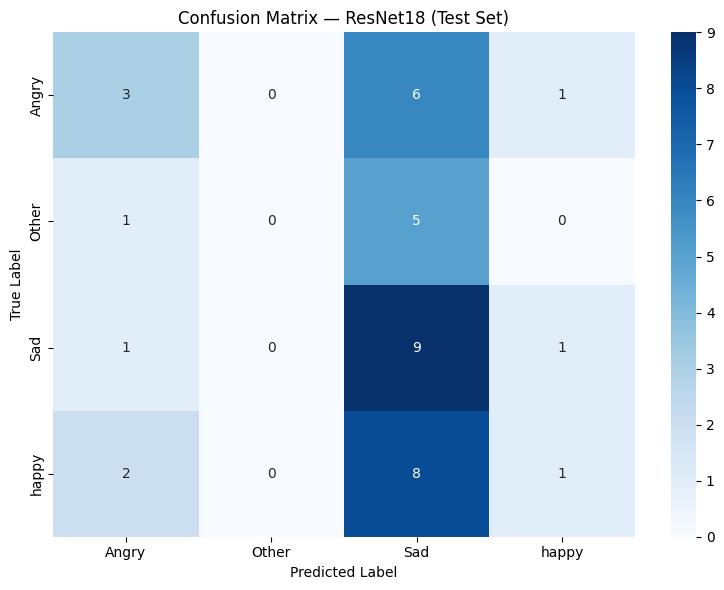

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from config import DEVICE # Pulling your device setting

def plot_test_confusion_matrix(model, test_loader, class_names, model_name="Model"):
    # 1. Put the model in evaluation mode (turns off dropout/batchnorm updates)
    model.eval() 
    
    all_preds = []
    all_labels = []

    # 2. Run the test set through the model
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            
            # Forward pass
            outputs = model(images)
            preds = outputs.argmax(1)
            
            # Send back to CPU and convert to numpy for sklearn/matplotlib
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 3. Calculate accuracy and generate the matrix
    test_acc = (all_preds == all_labels).mean()
    print(f'\n--- {model_name} Test Accuracy: {test_acc:.4f} ---') 
    
    cm = confusion_matrix(all_labels, all_preds)
    
    # 4. Plot the Seaborn heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

plot_test_confusion_matrix(trained_resnet, test_loader, class_names, model_name="ResNet18")


  Training : MobileNetV1  |  device: cuda
Epoch [ 1/30]  Train Loss: 1.4721  Train Acc: 0.2890  |  Val Loss: 1.7126  Val Acc: 0.1667
  Model saved with Val Acc: 0.1667
Epoch [ 2/30]  Train Loss: 1.4337  Train Acc: 0.2710  |  Val Loss: 1.6027  Val Acc: 0.2222
  Model saved with Val Acc: 0.2222
Epoch [ 3/30]  Train Loss: 1.4275  Train Acc: 0.2950  |  Val Loss: 1.4330  Val Acc: 0.2500
  Model saved with Val Acc: 0.2500
Epoch [ 4/30]  Train Loss: 1.4043  Train Acc: 0.3070  |  Val Loss: 1.3725  Val Acc: 0.3889
  Model saved with Val Acc: 0.3889
Epoch [ 5/30]  Train Loss: 1.3893  Train Acc: 0.3230  |  Val Loss: 1.3592  Val Acc: 0.3611
Epoch [ 6/30]  Train Loss: 1.3776  Train Acc: 0.3030  |  Val Loss: 1.3404  Val Acc: 0.4167
  Model saved with Val Acc: 0.4167
Epoch [ 7/30]  Train Loss: 1.3561  Train Acc: 0.3390  |  Val Loss: 1.3845  Val Acc: 0.4444
  Model saved with Val Acc: 0.4444
  EarlyStopping: no improvement for 1/5 epochs
Epoch [ 8/30]  Train Loss: 1.3866  Train Acc: 0.3060  |  Val Lo

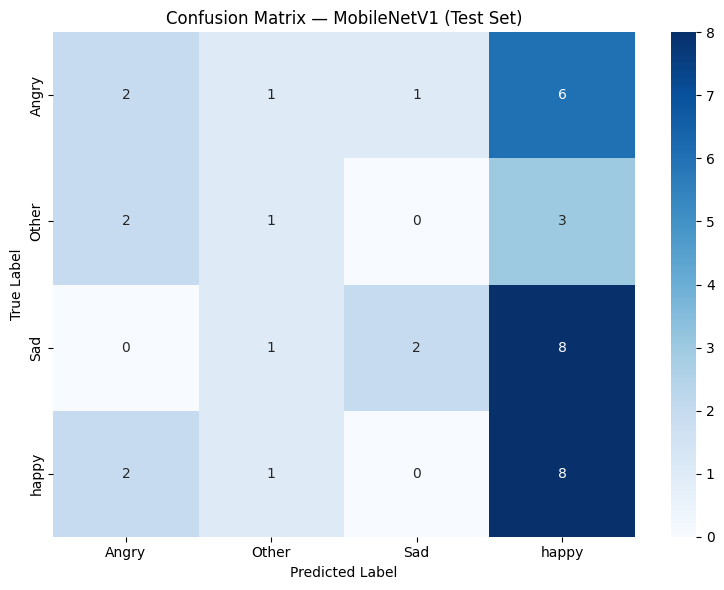

In [8]:
from models.mobilenet import MobileNet

mobilenet_model = MobileNet(num_classes=NUM_CLASSES)

trained_mobilenet, best_acc_mobile = train_model(
    model=mobilenet_model,
    model_name="MobileNetV1",
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=class_names
)
plot_test_confusion_matrix(trained_mobilenet, test_loader, class_names, model_name="MobileNetV1")